In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/titanic.csv') # read in the csv file

# 1. Remove attributes that just arent useful for us
del df['PassengerId']
del df['Name']
del df['Cabin']
del df['Ticket']

# 2. Impute some missing values, grouped by their Pclass and SibSp numbers
df_grouped = df.groupby(by=['Pclass','SibSp'])

# # now use this grouping to fill the data set in each group, then transform back
# fill in the numeric values
numeric_columns = ['Survived','Age','Parch','SibSp','Pclass','Fare'] # only transform numeric columns
df_imputed = df_grouped[numeric_columns].transform(lambda grp: grp.fillna(grp.median()))
# Extra step: fill any object columns that could not be transformed
col_deleted = list( set(df.columns) - set(df_imputed.columns)) # in case the median operation deleted columns
df_imputed[col_deleted] = df[col_deleted]


# fillin the grouped variables from original data frame
df_imputed[['Pclass','SibSp']] = df[['Pclass','SibSp']]

# 4. drop rows that still had missing values after grouped imputation
df_imputed.dropna(inplace=True)

# 5. Rearrange the columns
df_imputed = df_imputed[['Survived','Age','Sex','Parch','SibSp','Pclass','Fare','Embarked']]

# 6. Use One Hot Encoding
# perform one-hot encoding of the categorical data "embarked"
tmp_df = pd.get_dummies(df_imputed.Embarked,prefix='Embarked')
df_imputed = pd.concat((df_imputed,tmp_df),axis=1) # add back into the dataframe

tmp_df = pd.get_dummies(df_imputed.Sex,prefix='Sex')
df_imputed = pd.concat((df_imputed,tmp_df),axis=1) # add back into the dataframe

# Now let's clean up the dataset
if 'Sex' in df_imputed:
    del df_imputed['Sex'] # if 'Sex' column still exists, delete it (as we created an ismale column)
    
if 'Embarked' in df_imputed:    
    del df_imputed['Embarked'] # get reid of the original category as it is now one-hot encoded
    
# Finally, let's create a new variable based on the number of family members
# traveling with the passenger

# notice that this new column did not exist before this line of code--we use the pandas 
#    syntax to add it in 
df_imputed['FamilySize'] = df_imputed.Parch + df_imputed.SibSp
df_imputed.info()

<class 'pandas.DataFrame'>
Index: 882 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    882 non-null    int64  
 1   Age         882 non-null    float64
 2   Parch       882 non-null    int64  
 3   SibSp       882 non-null    int64  
 4   Pclass      882 non-null    int64  
 5   Fare        882 non-null    float64
 6   Embarked_C  882 non-null    bool   
 7   Embarked_Q  882 non-null    bool   
 8   Embarked_S  882 non-null    bool   
 9   Sex_female  882 non-null    bool   
 10  Sex_male    882 non-null    bool   
 11  FamilySize  882 non-null    int64  
dtypes: bool(5), float64(2), int64(5)
memory usage: 59.4 KB


In [2]:
from sklearn.model_selection import ShuffleSplit

# we want to predict the X and y data as follows:
if 'Survived' in df_imputed:
    y = df_imputed['Survived'].to_numpy() # get the labels we want
    del df_imputed['Survived'] # get rid of the class label
    
    norm_features = ['Age','Fare' ]
    df_imputed[norm_features] = (df_imputed[norm_features]-df_imputed[norm_features].mean()) / df_imputed[norm_features].std()
    X = df_imputed.to_numpy() # use everything else to predict!
    
    ## X and y are now numpy matrices, by calling 'values' on the pandas data frames we
    #    have converted them into simple matrices to use with scikit learn
    
X = X.astype(float)  

# to use the cross validation object in scikit learn, we need to grab an instance
#    of the object and set it up. This object will be able to split our data into 
#    training and testing splits
num_cv_iterations = 3
num_instances = len(y)
cv_object = ShuffleSplit(
                         n_splits=num_cv_iterations,
                         test_size  = 0.2)
                         
print(cv_object)

ShuffleSplit(n_splits=3, random_state=None, test_size=0.2, train_size=None)


In [3]:
# run logistic regression and vary some parameters
from sklearn import metrics as mt
from LarsonUtils import BinaryLogisticRegression

# first we create a reusable logisitic regression object
#   here we can setup the object with different learning parameters and constants
lr_clf = BinaryLogisticRegression(eta=0.1, iterations=10) # get object

# now we can use the cv_object that we setup before to iterate through the 
#    different training and testing sets. Each time we will reuse the logisitic regression 
#    object, but it gets trained on different data each time we use it.

for iter_num, (train_indices, test_indices) in enumerate(cv_object.split(X,y)):
    lr_clf.fit(X[train_indices],y[train_indices])  # train object
    y_hat = lr_clf.predict(X[test_indices]) # get test set precitions

    # print the accuracy and confusion matrix 
    print("====Iteration",iter_num," ====")
    print("accuracy", mt.accuracy_score(y[test_indices],y_hat)) 
    print("confusion matrix\n",mt.confusion_matrix(y[test_indices],y_hat))
    


====Iteration 0  ====
accuracy 0.751412429378531
confusion matrix
 [[87 18]
 [26 46]]
====Iteration 1  ====
accuracy 0.8361581920903954
confusion matrix
 [[101  12]
 [ 17  47]]
====Iteration 2  ====
accuracy 0.7401129943502824
confusion matrix
 [[88 16]
 [30 43]]


In [4]:
%%time

# alternatively, we can also graph out the values using boxplots
num_cv_iterations = 20
num_instances = len(y)
cv_object = ShuffleSplit(n_splits=num_cv_iterations,
                         test_size  = 0.5)

def lr_explor(cost):
    lr_clf = BinaryLogisticRegression(eta=0.1,iterations=10,
                                            C=float(cost)) # get object
    acc = []
    for iter_num, (train_indices, test_indices) in enumerate(cv_object.split(X,y)):
        lr_clf.fit(X[train_indices],y[train_indices])  # train object
        y_hat = lr_clf.predict(X[test_indices]) # get test set predictions
        acc.append(mt.accuracy_score(y[test_indices],y_hat))
        
    acc = np.array(acc)
    return acc

costs = np.logspace(-5,5,20)
accs = []
for c in costs:
    accs.append(lr_explor(c))

CPU times: user 480 ms, sys: 3.63 s, total: 4.11 s
Wall time: 264 ms


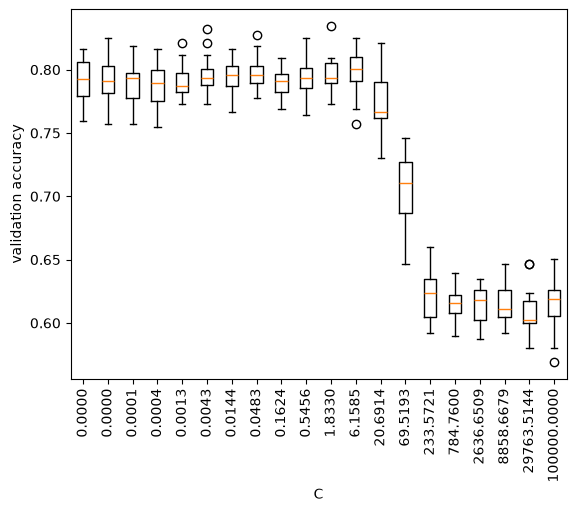

In [5]:
# now show a boxplot of the data across c
from matplotlib import pyplot as plt
%matplotlib inline

plt.boxplot(accs)
plt.xticks(range(1,len(costs)+1),['%.4f'%(c) for c in costs],rotation='vertical')
plt.xlabel('C')
plt.ylabel('validation accuracy')
plt.show()

# Comparison to Sklearn

In [6]:
# allow for the user to specify the algorithm they want to solver the binary case

class MultiClassLogisticRegression:
    def __init__(self, eta, iterations=20, 
                 C=0.0001, 
                 solver=BinaryLogisticRegression):
        self.eta = eta
        self.iters = iterations
        self.C = C
        self.solver = solver
        self.classifiers_ = []
        # internally we will store the weights as self.w_ to keep with sklearn conventions
    
    def __str__(self):
        if(hasattr(self,'w_')):
            return 'MultiClass Logistic Regression Object with coefficients:\n'+ str(self.w_) # is we have trained the object
        else:
            return 'Untrained MultiClass Logistic Regression Object'
        
    def fit(self,X,y):
        num_samples, num_features = X.shape
        self.unique_ = np.sort(np.unique(y)) # get each unique class value
        num_unique_classes = len(self.unique_)
        self.classifiers_ = []
        for i,yval in enumerate(self.unique_): # for each unique value
            y_binary = np.array(y==yval).astype(int) # create a binary problem
            # train the binary classifier for this class
            
            hblr = self.solver(eta=self.eta, iterations=self.iters, C=self.C)
            hblr.fit(X,y_binary)

            # add the trained classifier to the list
            self.classifiers_.append(hblr)
            
        # save all the weights into one matrix, separate column for each class
        self.w_ = np.hstack([x.w_ for x in self.classifiers_]).T
        
    def predict_proba(self,X):
        probs = []
        for hblr in self.classifiers_:
            probs.append(hblr.predict_proba(X).reshape((len(X),1))) # get probability for each classifier
        
        return np.hstack(probs) # make into single matrix
    
    def predict(self,X):
        return self.unique_[np.argmax(self.predict_proba(X),axis=1)] # take argmax along row
    


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
import numpy as np
from sklearn.metrics import accuracy_score
from scipy.special import expit
from sklearn.model_selection import train_test_split

ds = load_iris()
X = ds.data

X = StandardScaler().fit(X).transform(X)
y_not_binary = ds.target # note problem is NOT binary anymore, there are three classes!
X_train, X_test, y_train, y_test = train_test_split(X,y_not_binary, train_size = 0.8, test_size=0.2)


In [15]:
%%time

lr = MultiClassLogisticRegression(eta=50.0,
                                  iterations=20,
                                  C=0.0,
                                 )
lr.fit(X_train,y_train)
print(lr)

yhat = lr.predict(X_test)
print('Accuracy of: ',accuracy_score(y_test,yhat))

MultiClass Logistic Regression Object with coefficients:
[-4.83194990e+00 -1.85065700e-02  3.46786913e+00 -5.95830715e+00
 -3.52189194e+00 -9.99648262e-01 -1.84873062e-03 -1.56218589e+00
  2.09207681e+00 -2.22434664e+00 -1.54455978e+01 -2.51618545e+00
 -1.58322900e+00  1.36106670e+01  1.15606563e+01]
Accuracy of:  0.9666666666666667
CPU times: user 6.29 ms, sys: 2.54 ms, total: 8.83 ms
Wall time: 6.58 ms


In [16]:
from sklearn.linear_model import LogisticRegression

In [17]:
%%time

lr_sk = LogisticRegression(solver='lbfgs',
                        C = np.inf, 
                          max_iter=20) # all params default
# note that sklearn is optimized for using the liblinear library with logistic regression
# ...and its faster than our implementation here

lr_sk.fit(X_train, y_train) # no need to add bias term, sklearn does it internally!!
print(lr_sk.coef_)
yhat = lr_sk.predict(X_test)
print('Accuracy of: ',accuracy_score(y_test,yhat))

[[-4.39968443  4.65494225 -7.4290538  -7.08766008]
 [ 3.51295128 -1.47456296 -3.57891554 -2.52665446]
 [ 0.88673315 -3.18037929 11.00796934  9.61431453]]
Accuracy of:  0.9666666666666667
CPU times: user 8.61 ms, sys: 2.46 ms, total: 11.1 ms
Wall time: 8.79 ms


/Users/eclarson/anaconda3/envs/mlenv3_12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=20).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
